### Today task is to compare the performance of:
	•	A CNN trained from scratch
	•	A model using Transfer Learning (MobileNetV2)

for classifying flower images.



#### After this lab, students will be able to:
	•	Build a CNN model from scratch
	•	Apply transfer learning using a pre-trained network
	•	Compare training accuracy, Precision and Recall
	•	Analyze learning curves
	•	Understand why transfer learning is effective

#### 🧑‍🎓 Student Details

| Field                | Information                |
|---------------------|----------------------------|
| 👨‍🎓 **Name**            | _[Enter Your Full Name]_     |
| 🆔 **USN**              | _[Enter Your USN]_           |
| **Section**        | _[Enter Your Section]_ |
| **Programme**   | B.Tech(H)             |
| **School**  | Computer Science and Engineering |


### Transfer Learning reuses knowledge learned from large datasets (e.g., ImageNet) to solve new problems efficiently.

#### Key idea:
	•	Early CNN layers learn generic features (edges, textures)
	•	Later layers learn task-specific features
	•	We reuse earlier layers and train only new layers


**Task 01:** Load the important libraries

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import cv2
import tensorflow as tf
from tensorflow.keras import layers

**Task 02:** Load Dataset

We use the TensorFlow Flower dataset containing 5 classes.

In [3]:
import tensorflow as tf

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

print("data_dir =", data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
data_dir = /root/.keras/datasets/flower_photos


**Task 03:** Data Exploration

In [4]:
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"
    print("Fixed data_dir =", data_dir)

Fixed data_dir = /root/.keras/datasets/flower_photos/flower_photos


In [5]:
print("Total jpg:", len(list(data_dir.glob("*/*.jpg"))))
print("Class counts:")
for cls in ["roses","daisy","dandelion","sunflowers","tulips"]:
    print(cls, len(list(data_dir.glob(f"{cls}/*.jpg"))))

Total jpg: 3670
Class counts:
roses 641
daisy 633
dandelion 898
sunflowers 699
tulips 799


In [6]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

**Task 04:** — Create Training and Validation Sets

In [8]:
IMG_SIZE = (180, 180)      # Fill
BATCH_SIZE = 32             # Fill
SEED = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "training",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


**Task 05:** Visualizing Simple Images for Pre-check

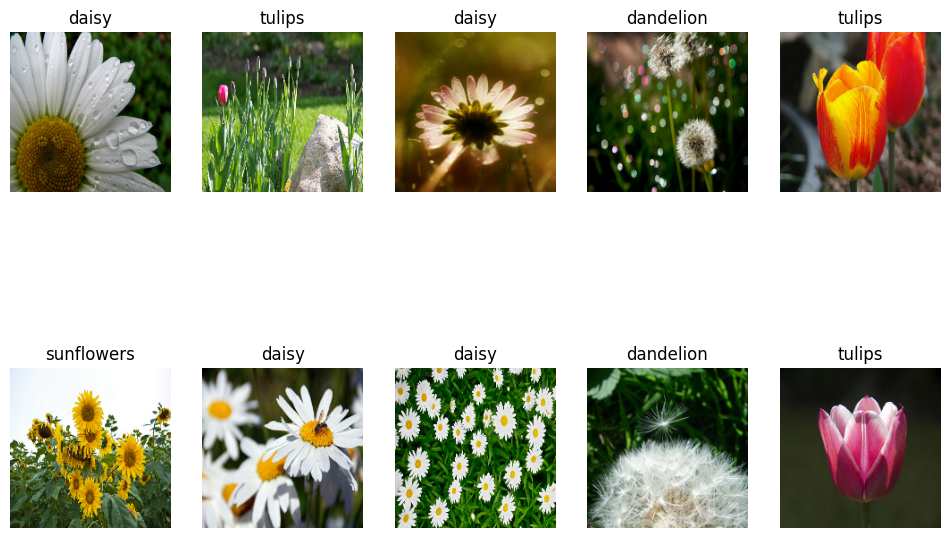

In [9]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.show()

**Task 06:** — Optimize Dataset Pipeline

In [20]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

normalizer = layers.Rescaling(1./255)

**Task 07** -- Implement CNN without Transfer Learning

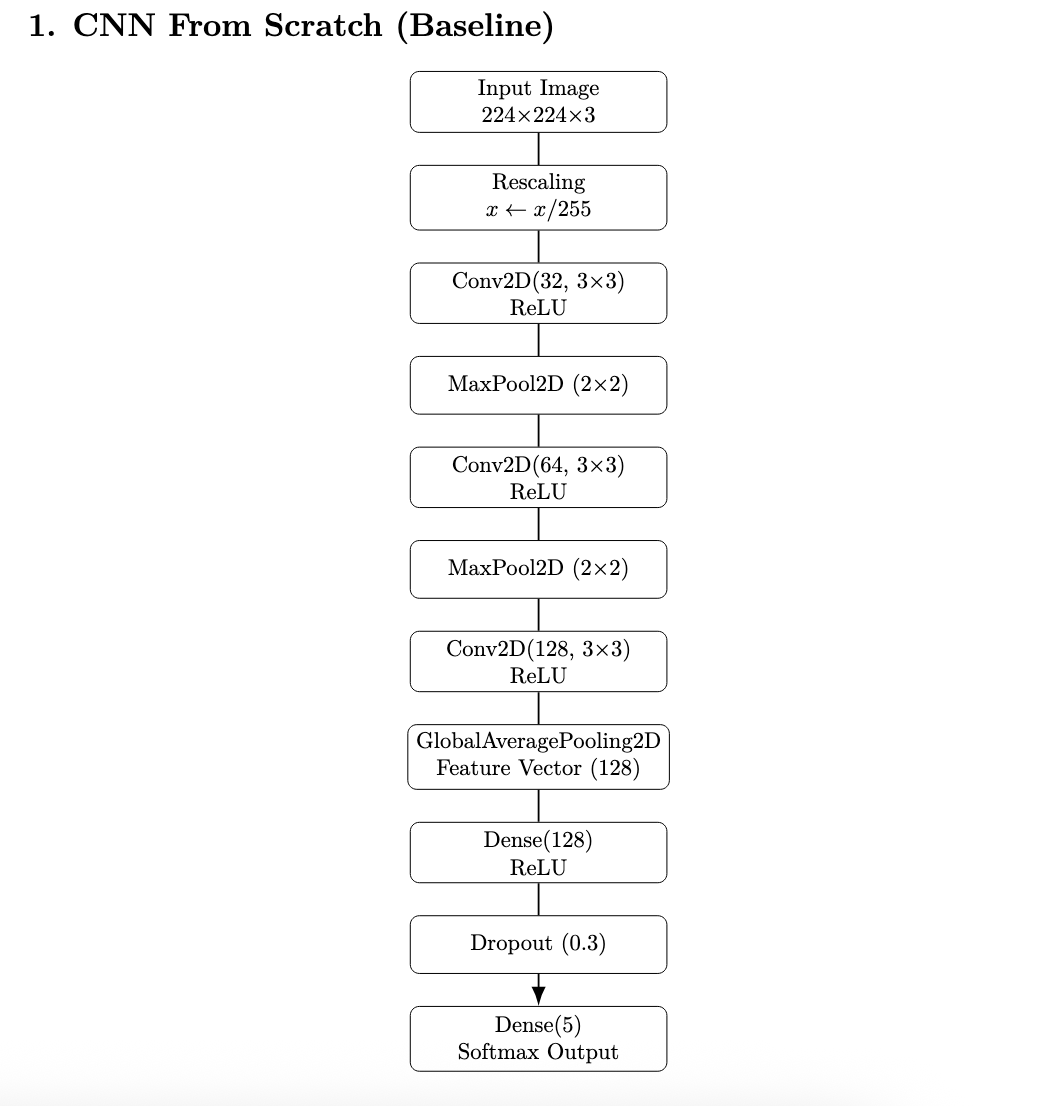

In [21]:
baseline_model = tf.keras.Sequential([

    layers.Input(shape = IMG_SIZE + (3,)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

**Task 08:** Train the baseline model for study

In [19]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.2872 - loss: 1.5524 - val_accuracy: 0.3992 - val_loss: 1.2510
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4197 - loss: 1.3030 - val_accuracy: 0.5163 - val_loss: 1.1427
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5137 - loss: 1.1698 - val_accuracy: 0.5232 - val_loss: 1.1034
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5495 - loss: 1.0986 - val_accuracy: 0.5899 - val_loss: 1.0533
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5584 - loss: 1.0725 - val_accuracy: 0.6199 - val_loss: 1.0358
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5827 - loss: 1.0503 - val_accuracy: 0.5736 - val_loss: 1.0713
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5888 - loss: 1.0450 - val_accuracy: 0.6117 - val_loss: 0.9418
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6231 - loss: 0.9514 - val_accuracy: 0.6294 - 

Task 09: Implement the CNN with Transfer Learning using MobileVnet Model [ Lightweight ]

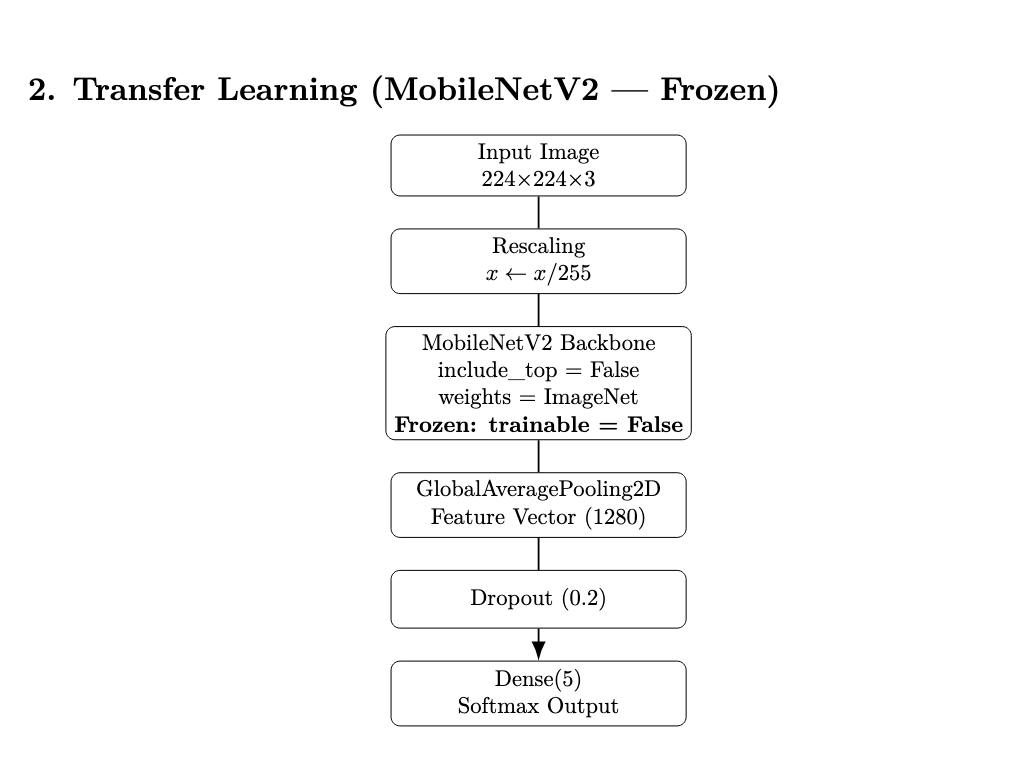

In [16]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,    # Fill
    weights = 'imagenet'         # Fill
)

base_model.trainable = False  # Freeze or not?

tl_model = tf.keras.Sequential([
    layers.Input(shape = IMG_SIZE + (3,)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),   # Fill
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

/tmp/ipykernel_372/2407015849.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
tl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Task 10:** Train the tranfer learning model

In [18]:
history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 53s 333ms/step - accuracy: 0.4719 - loss: 1.3376 - val_accuracy: 0.8065 - val_loss: 0.5282
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8257 - loss: 0.4885 - val_accuracy: 0.8460 - val_loss: 0.4311
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8706 - loss: 0.3798 - val_accuracy: 0.8542 - val_loss: 0.3960
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8894 - loss: 0.3303 - val_accuracy: 0.8624 - val_loss: 0.3761
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9059 - loss: 0.2907 - val_accuracy: 0.8583 - val_loss: 0.3909
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9092 - loss: 0.2628 - val_accuracy: 0.8706 - val_loss: 0.3798
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9219 - loss: 0.2490 - val_accuracy: 0.8638 - val_loss: 0.4023
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9352 - loss: 0.2033 - val_accuracy: 0.8556 -

#Compare the Learning curves of both

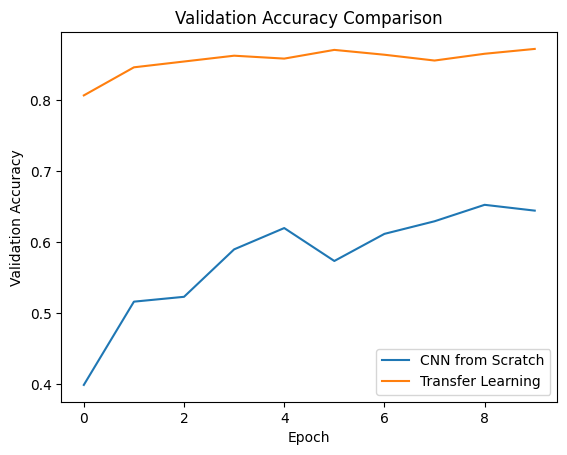

In [22]:
plt.figure()

plt.plot(history_baseline.history["val_accuracy"],
         label="CNN from Scratch")

plt.plot(history_tl.history["val_accuracy"],
         label="Transfer Learning")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()

### Performance Comparison Table

In [23]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Model": "CNN from Scratch",
        "Epochs": len(history_baseline.history["val_accuracy"]),
        "Total Params": baseline_model.count_params(),
        "Best Val Acc": max(history_baseline.history["val_accuracy"])
    },
    {
        "Model": "Transfer Learning",
        "Epochs": len(history_tl.history["val_accuracy"]),
        "Total Params": tl_model.count_params(),
        "Best Val Acc": max(history_tl.history["val_accuracy"])
    }
])

summary

,Model,Epochs,Total Params,Best Val Acc
0,CNN from Scratch,10,110405,0.652589
1,Transfer Learning,10,2264389,0.871935


## Answer the following questions:

1. Which model converges faster?
2. Which model shows higher validation accuracy?
3. Does CNN from scratch show signs of overfitting? Explain.
4. Why does TL have many parameters but few trainable ones?
5. Why does freezing layers reduce training time?
6. Which model requires more data to train effectively?

## Prediction on Validation Data

In [24]:
import numpy as np

def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)     # (batch, num_classes)
        preds = np.argmax(probs, axis=1)             # predicted class index

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

y_true_base, y_pred_base = get_true_and_pred(baseline_model, val_ds)
y_true_tl,   y_pred_tl   = get_true_and_pred(tl_model, val_ds)

In [25]:
acc_base = (y_true_base == y_pred_base).mean()
acc_tl   = (y_true_tl == y_pred_tl).mean()

print("Baseline CNN Test Accuracy:", round(acc_base, 4))
print("Transfer Learning Test Accuracy:", round(acc_tl, 4))

Baseline CNN Test Accuracy: 0.1294
Transfer Learning Test Accuracy: 0.8719


<Figure size 640x480 with 0 Axes>

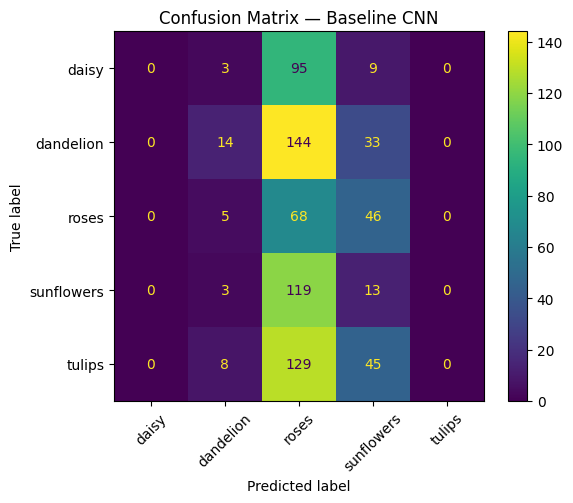

<Figure size 640x480 with 0 Axes>

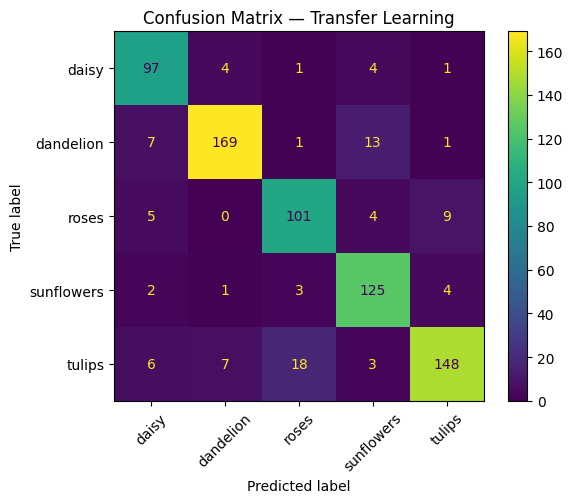

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_base = confusion_matrix(y_true_base, y_pred_base)
cm_tl   = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure()
ConfusionMatrixDisplay(cm_base, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Baseline CNN")
plt.show()

plt.figure()
ConfusionMatrixDisplay(cm_tl, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Transfer Learning")
plt.show()

## Answer the following questions:

1. Which classes are most confused by CNN from scratch?
2. Which class shows highest accuracy in TL model?
3. Why might “roses” be harder to classify than “sunflowers”?

In [27]:
from sklearn.metrics import classification_report

print("=== Baseline CNN Report ===")
print(classification_report(y_true_base, y_pred_base, target_names=class_names))

print("=== Transfer Learning Report ===")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

=== Baseline CNN Report ===
              precision    recall  f1-score   support

       daisy       0.00      0.00      0.00       107
   dandelion       0.42      0.07      0.12       191
       roses       0.12      0.57      0.20       119
  sunflowers       0.09      0.10      0.09       135
      tulips       0.00      0.00      0.00       182

    accuracy                           0.13       734
   macro avg       0.13      0.15      0.08       734
weighted avg       0.15      0.13      0.08       734

=== Transfer Learning Report ===
              precision    recall  f1-score   support

       daisy       0.83      0.91      0.87       107
   dandelion       0.93      0.88      0.91       191
       roses       0.81      0.85      0.83       119
  sunflowers       0.84      0.93      0.88       135
      tulips       0.91      0.81      0.86       182

    accuracy                           0.87       734
   macro avg       0.86      0.88      0.87       734
weighted avg    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Answer the following questions:

1.	Which class has lowest F1-score in baseline CNN?
2.	How much did overall accuracy improve using TL?
3.	Why does precision differ from recall?

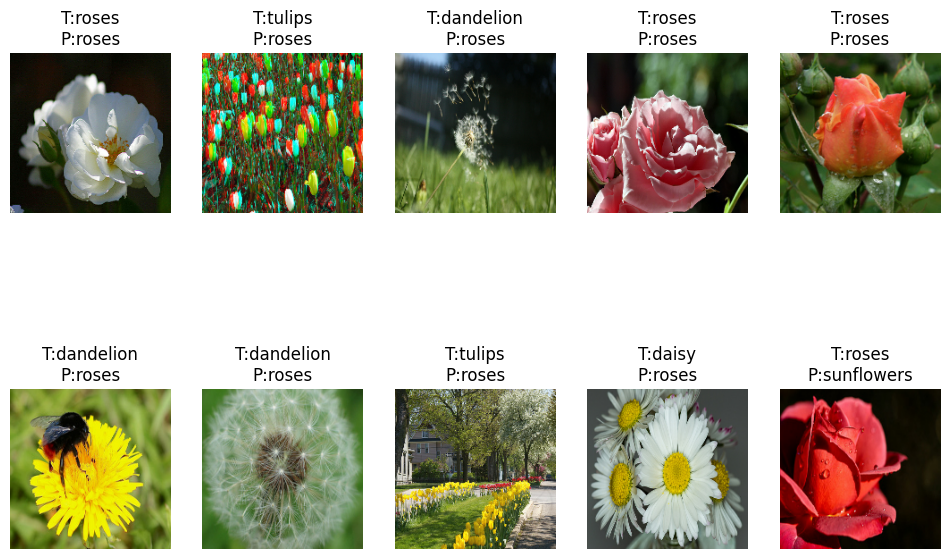

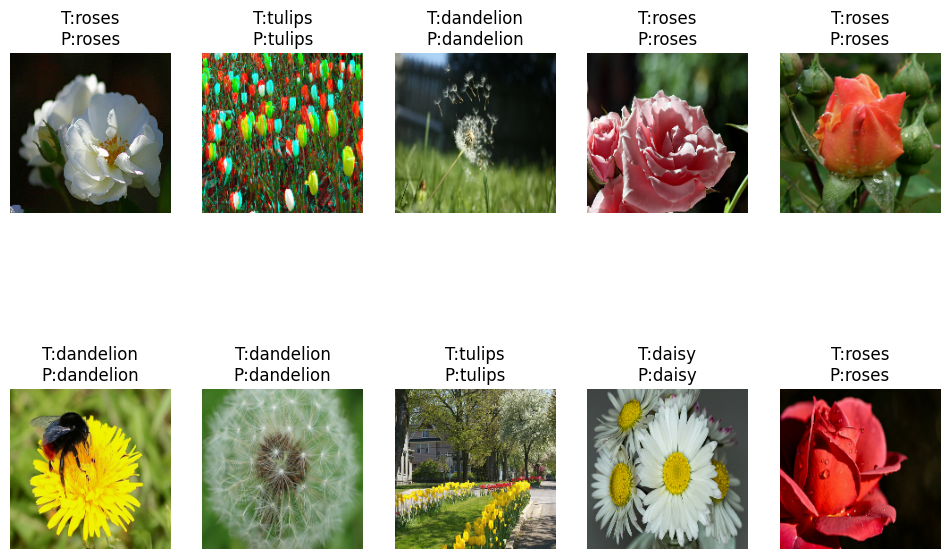

In [28]:
import matplotlib.pyplot as plt

def show_prediction_grid(model, dataset, class_names, n=10):
    images, labels = next(iter(dataset))
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(12,8))
    for i in range(n):
        ax = plt.subplot(2, 5, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        t = class_names[int(labels[i])]
        p = class_names[int(preds[i])]
        plt.title(f"T:{t}\nP:{p}")
        plt.axis("off")
    plt.show()

show_prediction_grid(baseline_model, val_ds, class_names, n=10)
show_prediction_grid(tl_model, val_ds, class_names, n=10)

Questions:

	1.	Why does TL have many parameters but few trainable ones?
	2.	Why does freezing layers reduce training time?
	3.	Which model requires more data to train effectively?

## Test on new data

In [29]:
from google.colab import files
uploaded = files.upload()


Saving image.png to image (1).png


In [30]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

IMG_SIZE = (224, 224)

def preprocess_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

In [31]:
test_image = preprocess_image("img03.jpg")

predictions = tl_model.predict(test_image)

predicted_class = np.argmax(predictions[0])
confidence = np.max(predictions[0])

print("Predicted Flower:", class_names[predicted_class])
print("Confidence:", round(confidence*100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Predicted Flower: roses
Confidence: 99.34 %


**Final Task for Students:** Fine-Tuning Task - Unfreeze last layers of MobileNetV2 and retrain for 3 epochs.

Interpret:

	•	Accuracy change
	•	Overfitting risk

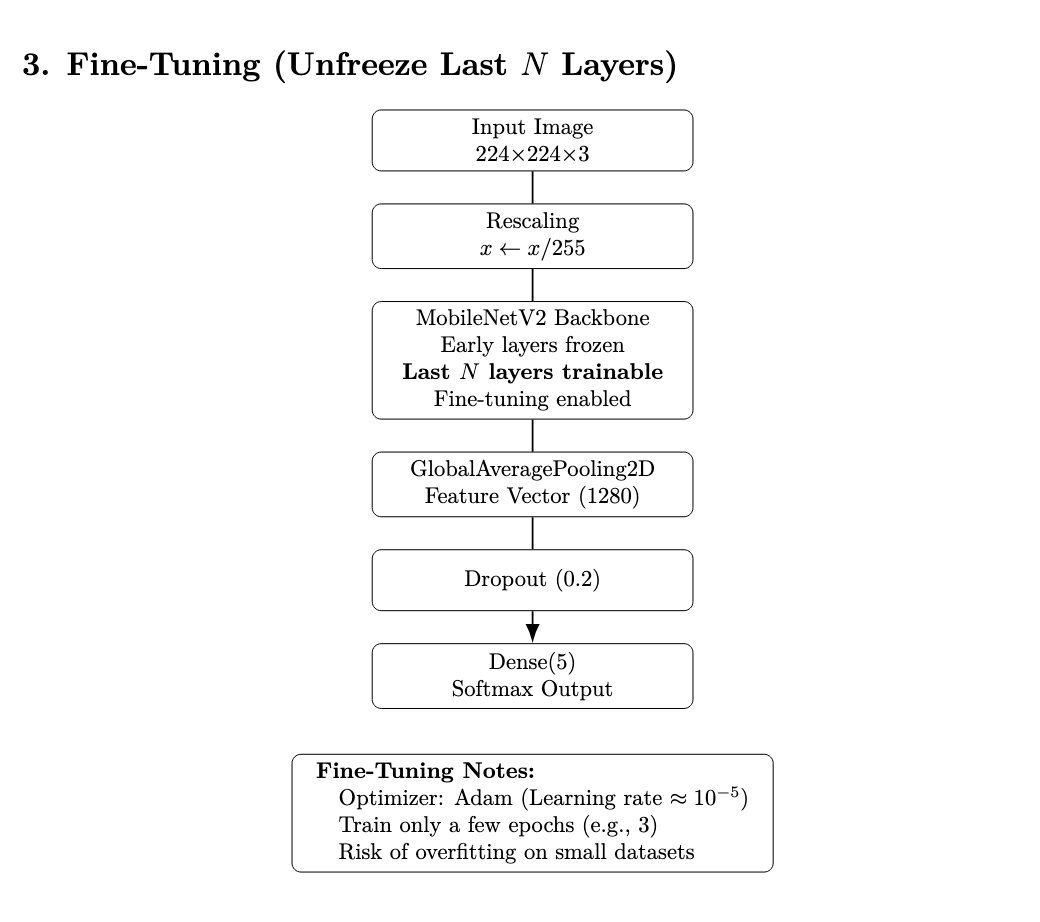